# A Leakage-Conscious, Physics-Guided Wellbore Trajectory Study

**Metric:** row-level RMSE in feet (lower is better)

This one's about predicting the hidden trajectory of a horizontal well's geology from its drilled path, a noisy gamma-ray log, a short visible stretch of true vertical thickness, and a paired vertical reference well. I started with a strong nonlinear baseline, but the most important change I made wasn't another model, it was changing what I was willing to count as a valid experiment. Nearby wells, copied type-well curves, and near-identical GR sequences kept crossing my ordinary well folds. So I switched to geological-component splits and started scoring every correction as a frozen, bounded update to a named parent prediction.

The path I ended up deploying combines a local ML reference, a particle-filter trajectory, a GeoHMM alignment path, an HGRG movement gate, a regional Meta-State direction, a visible-prefix boundary condition, and a small conditional GeoHMM shape correction. I also tried CHRRC and a nested residual stack as controlled side experiments, not every experiment that worked made it into the final CSV. None of these pieces share one universal validation score, so I'm only reporting each result inside its own contract.

The strongest findings:

- PF + 20% GeoHMM: **7.5072 -> 6.5775** on a 40-well discovery panel;
- HGRG: **7.8299 -> 7.5006** on an 80-well transfer surrogate;
- Meta-State: **9.8871 -> 9.1804** on a 160-well transfer panel I reused, with predictions frozen inside that run;
- nested residual stacking: **9.1804 -> 9.1087** on the same 160-well confirmation;
- Prefix-Boundary plus conditional shape: **7.4324 -> 7.3986** on Exact80, though that composition never got a fresh, untouched confirmation panel.

These come from different parents and populations, so I'm not adding the gains together or presenting them as one hidden-score estimate.

The final Boundary + Meta + conditional-shape run hit **9.091 hidden RMSE**, comfortably inside the bronze range shown on the leaderboard. More on what happened with that submission at the very end of this note, I'd rather not turn the whole thing into a chronological list of my submissions.

## How to read this notebook

Everything here is rebuilt from compact, hash-checked evidence pulled out of my saved experiment artifacts, it reproduces the tables, pooled metrics, and figures without rerunning the multi-hour trajectory inference itself.

Three rules I stuck to throughout:

1. gain = base RMSE − candidate RMSE, so positive means better;
2. I only compare absolute RMSE values inside the same named validation contract;
3. a method only gets promoted after its weights are frozen without seeing the labels it's evaluated on.

The component-bootstrap intervals you'll see are calculated after a policy is already selected and frozen. They tell you about geological-component sampling variability given that policy, they're not selection-adjusted confidence intervals, and they don't erase the fact that I looked at some of these panels more than once.

In [1]:
from pathlib import Path
import hashlib
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_colwidth", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.rcParams.update({
    "figure.figsize": (9.5, 4.8),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "font.size": 10.5,
})

candidates = [
    Path("evidence"),
    Path("kaggle_working_note_v2/evidence"),
    Path("/kaggle/input/rogii-working-note-evidence/evidence"),
    Path("/kaggle/input/rogii-working-note-evidence"),
]
EVIDENCE = next((path for path in candidates if (path / "manifest.json").exists()), None)
if EVIDENCE is None:
    raise FileNotFoundError("Could not find the compact evidence directory.")

def file_sha256(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

manifest = json.loads((EVIDENCE / "manifest.json").read_text())
mismatches = {
    name: (expected, file_sha256(EVIDENCE / name))
    for name, expected in manifest["bundle_sha256"].items()
    if file_sha256(EVIDENCE / name) != expected
}
assert not mismatches, f"Evidence hash mismatch: {mismatches}"
print(f"Verified {len(manifest['bundle_sha256'])} public evidence files.")

Verified 20 public evidence files.


In [2]:
leakage = pd.read_csv(EVIDENCE / "leakage_rates.csv")
results = pd.read_csv(EVIDENCE / "validation_results.csv")
pipeline = pd.read_csv(EVIDENCE / "pipeline_components.csv")
negatives = pd.read_csv(EVIDENCE / "negative_results.csv")
transfer_pairs = pd.read_csv(EVIDENCE / "transfer_pairs.csv")
full_wells = pd.read_csv(EVIDENCE / "full_component_oof_per_well.csv")
stack_wells = pd.read_csv(EVIDENCE / "residual_stack_per_well.csv")
stack_folds = pd.read_csv(EVIDENCE / "residual_stack_fold_metrics.csv")
stack_weights = pd.read_csv(EVIDENCE / "residual_stack_weights.csv")
nonlinear_wells = pd.read_csv(EVIDENCE / "nonlinear_control_oof_per_well.csv")
nonlinear_parameters = pd.read_csv(EVIDENCE / "nonlinear_control_parameters.csv")
nonlinear_blends = pd.read_csv(EVIDENCE / "nonlinear_control_blends.csv")
nonlinear_scores = pd.read_csv(EVIDENCE / "nonlinear_control_official_scores.csv")
chrrc_grid = pd.read_csv(EVIDENCE / "chrrc_calibration_grid.csv")
rmse_ladders = pd.read_csv(EVIDENCE / "rmse_ladders.csv")
horizon_rmse = pd.read_csv(EVIDENCE / "horizon_rmse.csv")
weight_provenance = pd.read_csv(EVIDENCE / "deployment_weight_provenance.csv")
complexity_ledger = pd.read_csv(EVIDENCE / "complexity_ledger.csv")
final_result = json.loads((EVIDENCE / "final_result.json").read_text())

full_rmse = np.sqrt(np.average(full_wells.rmse**2, weights=full_wells.rows))
assert np.isclose(full_rmse, 13.0384924873, atol=1e-8)
nonlinear_raw = np.sqrt(nonlinear_wells.raw_sse.sum() / nonlinear_wells.rows.sum())
nonlinear_chrrc = np.sqrt(nonlinear_wells.chrrc_sse.sum() / nonlinear_wells.rows.sum())
assert np.isclose(nonlinear_raw, 13.6549564654, atol=1e-8)
assert np.isclose(nonlinear_chrrc, 13.6065092658, atol=1e-8)

def pooled_from_wells(panel, column):
    part = stack_wells[stack_wells.panel.eq(panel)]
    return np.sqrt(np.average(part[column]**2, weights=part.rows))

assert np.isclose(pooled_from_wells("Dev160", "identity_parent_rmse"), 9.5440920865, atol=1e-8)
assert np.isclose(pooled_from_wells("Dev160", "hybrid_convex_rmse"), 9.4643644077, atol=1e-8)
assert np.isclose(pooled_from_wells("Confirmation160", "identity_parent_rmse"), 9.1804188196, atol=1e-8)
assert np.isclose(pooled_from_wells("Confirmation160", "hybrid_convex_rmse"), 9.1087123604, atol=1e-8)
assert np.allclose(results.base_rmse - results.candidate_rmse, results.gain, atol=5e-7)

display(results[["experiment", "contract", "base_rmse", "candidate_rmse", "gain", "positive_folds", "role"]])

,experiment,contract,base_rmse,candidate_rmse,gain,positive_folds,role
0,Nonlinear LightGBM + frozen CHRRC,Exact 773-well component OOF,13.6550,13.6065,0.0484,5.0000,stable nonlinear control; weak absolute trajectory base
1,CHRRC bounded roughness controller,Component-held controller audit,12.9483,12.8883,0.0600,5.0000,validated local controller
2,PF + 20% GeoHMM,40-well trajectory discovery,7.5072,6.5775,0.9297,NaN,strong discovery; not a full-pipeline estimate
3,HGRG bounded trajectory update,80-well transfer surrogate,7.8299,7.5006,0.3293,4.0000,promising transfer result
4,Meta-State reliability scaler,160-well repeated transfer (within-run frozen),9.8871,9.1804,0.7067,5.0000,replicated direction; panel was not historically pristine
5,Prefix-Boundary hand-off,80-well transfer surrogate,7.4324,7.4141,0.0183,4.0000,small physical hand-off correction
6,Conditional stride-6 GeoHMM shape,80-well transfer surrogate,7.4324,7.4165,0.0160,4.0000,small frozen shape-only correction
7,Nested residual convex stack,160-well development,9.5441,9.4644,0.0797,4.0000,passed frozen development gate
8,Nested residual convex stack,160-well repeated transfer (within-run frozen),9.1804,9.1087,0.0717,5.0000,small confirmed overlay


## 1. What I was actually asked to predict

Each horizontal well comes with its measured depth (`MD`), its known 3-D trajectory (`X`, `Y`, `Z`), a gamma-ray log (`GR`) that's noisy and sometimes missing, and true vertical thickness (`TVT`) that's only visible up to a Prediction Start point. Each well is also paired with a **typewell**, a vertical reference well with its own `GR`–`TVT` curve. The job is to fill in the missing tail of `TVT`, which is a geological/stratigraphic coordinate rather than just the borehole's vertical position, scored as row-level RMSE in feet.

I rewrote that target as a structural coordinate

$$
U(s)=TVT(s)+Z(s), \qquad TVT(s)=U(s)-Z(s),
$$

where $s$ is measured depth and $Z$ is the known vertical coordinate of the borehole. This separates the motion of the well itself from the motion of the geological surface. The visible prefix anchors datum and short-range dip, while GR and the type-well log give ambiguous evidence about how things line up further out.

That reframing changed what I was actually trying to model. Instead of asking one row-wise regressor to infer the whole suffix on its own, I started treating PF, GeoHMM, and the spatial state as noisy measurements of one latent path. The learned model stayed the reference; the physical models only proposed bounded moves away from it.

## 2. Why my well folds weren't actually isolating anything

My first split grouped rows by well, so no well showed up in both train and validation. That sounds fine, but it didn't isolate local geology at all, the nearest geographic neighbor crossed folds for 635 of 773 wells, and most close or highly similar well pairs did too.

So I built connected components out of proximity, Prediction Start proximity, exact type-well identity, and high GR-curve similarity, assigned whole components to folds, and reused those same components as bootstrap units. I never pinned down the coordinate reference system for X/Y, so I'm reporting raw coordinate units instead of a real physical distance.

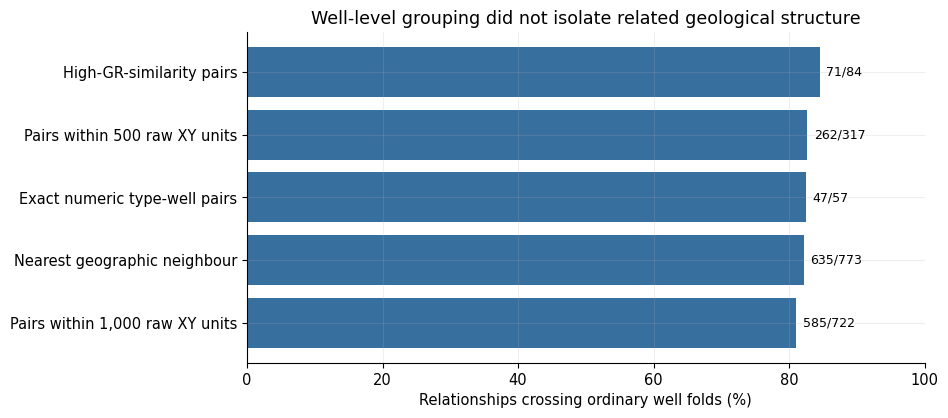

,relationship,cross_fold_count,total_count,cross_fold_rate
0,Nearest geographic neighbour,635,773,0.8215
1,Pairs within 500 raw XY units,262,317,0.8265
2,"Pairs within 1,000 raw XY units",585,722,0.8102
3,Exact numeric type-well pairs,47,57,0.8246
4,High-GR-similarity pairs,71,84,0.8452


In [3]:
plot = leakage.sort_values("cross_fold_rate")
fig, ax = plt.subplots(figsize=(9.6, 4.3))
bars = ax.barh(plot.relationship, 100 * plot.cross_fold_rate, color="#376f9f")
ax.set_xlim(0, 100)
ax.set_xlabel("Relationships crossing ordinary well folds (%)")
ax.set_title("Well-level grouping did not isolate related geological structure")
for bar, (_, row) in zip(bars, plot.iterrows()):
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{int(row.cross_fold_count)}/{int(row.total_count)}",
        va="center",
        fontsize=9,
    )
plt.tight_layout()
plt.show()
display(leakage)

## 3. The pipeline

Here's the sequence I ended up with. Every arrow passes along an ordered prediction vector with an ID/order checksum.

`component-safe data` -> `observable ML reference` -> `PF and GeoHMM trajectories` -> `HGRG projection` -> `Meta-State scaling` -> `Prefix-Boundary` -> `conditional GeoHMM shape`

The important design choice: later stages never replace the path without limit. Each one estimates a direction, scales it using target-free disagreement features, and projects it onto a per-well movement budget.

### What I can and can't claim about the weights

Fair criticism up front: this stack has a lot of decimals, and they don't all carry the same weight of evidence. Some were picked inside grouped OOF and then frozen. Some are fail-closed physical caps. A few were just inherited from the incumbent before I rebuilt leakage-safe validation. Freezing a transfer cuts down on adaptive fitting, but it doesn't turn an old tuned constant into a fully nested estimate, especially once I've already looked at the transfer panels.

If you put me at a whiteboard, I'd defend the shape of these updates far more confidently than any individual decimal: nonnegative combinations of independent paths, covariance-aware state fusion, mean-zero shape correction, exponential boundary release, explicit movement projections. I've labeled where each number came from in the table below so "0.25" doesn't look more certain than it actually is.

In [4]:
display(pipeline[["stage", "component", "input", "output", "physical_or_statistical_role", "inference_control"]])
display(weight_provenance[["stage", "quantity", "value", "evidence_class", "caveat"]])

,stage,component,input,output,physical_or_statistical_role,inference_control
0,0,Leakage-component split,"well location, start location, type-well identity, GR similarity",five grouped folds,keeps locally related geology on one side of validation,no target values
1,1,Observable ML reference,"prefix measurements, trajectory geometry, GR and type-well descriptors",row-wise structural reference,learns local nonlinear residual structure,outer-component OOF only for research scoring
2,2,Particle filter (PF),visible heel state and sequential GR observations,one-sided sequential structural trajectory,propagates uncertain datum and dip along measured depth,fixed seed set; suffix targets excluded
3,3,GeoHMM smoother,observable suffix GR and type-well GR,bidirectional alignment trajectory,preserves alternative GR alignments and long-range shape,"used as a bounded direction, not a standalone replacement"
4,4,HGRG,"reference, PF, GeoHMM and their disagreement",projected trajectory correction,moves only where independent trajectories agree,2.5-ft well-RMS budget and 10-ft row cap
5,5,Meta-State scaler,outer-fold spatial state and prediction-only reliability ratios,bounded regional trend overlay,adds cross-well datum/slope/curvature information,5-ft well-RMS budget and 10-ft row cap
6,6,Prefix-Boundary hand-off,visible-prefix structural tangent and Meta-State path,near-boundary continuity correction,softly enforces datum/slope continuity and releases it with horizon,prefix-only tangent; 2.5-ft well-RMS and 10-ft row caps
7,7,Conditional GeoHMM shape,"stride-6 GeoHMM, PF and prediction-only reliability",zero-mean long-range shape correction,adds alignment shape without moving the well datum,0.75-ft well-RMS and 2.5-ft row caps; overlap wells immutable
8,8,Research-only residual/CHRRC controls,nested residual experts or within-well roughness,audited alternative post-processors,tests error complementarity and removes tree-scale wiggle,not presented as part of the final Boundary+Meta+shape path


,stage,quantity,value,evidence_class,caveat
0,Incumbent SP45,Ridge / PF selector,0.30 / 0.70,inherited production constant,not re-estimated in one full nested study
1,Incumbent SP45,cubic projection weight,0.75,inherited production constant,"robust projection, but historical selection exposure"
2,Incumbent,SP45 / learned trajectory,0.60 / 0.40,inherited production constant,not a single-parent ablation on the final path
3,Learned branch,model / likelihood PF,0.55 / 0.45,inherited production constant,not re-estimated in one full nested study
4,Learned branch,warm-up / tilt / SG,"85 ft / ±0.18 ft / (61,3)",inherited shape controls,"mechanistically motivated, historically tuned"
5,Nonlinear package,disagreement gate,"0.00425, scale 6 ft, p95 cutoff 25 ft",frozen fail-closed guardrail,visible canary disabled this branch
6,HGRG,PF seeds / particles / HMM stride,12 / 500 / 2,frozen inference design,compute scale is not a fitted uncertainty distribution
7,HGRG,midpoint / RMS budget / row cap,0.50 / 2.5 ft / 10 ft,development-frozen bounded policy,transferred 4/5 folds on Exact80
8,Meta-State,PF / HMM / structural priors,0.65 / 0.25 / 0.10,fixed state-model priors,"GLS adapts them, but priors were not fully nested"
9,Meta-State,PF-HMM / structural correlation,0.20 / 0.10,fixed covariance assumptions,sensitivity is more important than decimal precision


### 3.1 Observable ML reference

I built a nonlinear row-wise reference out of prefix-derived trajectory geometry, GR summaries, and type-well descriptors. For honest scoring, every prediction for a component had to come from a model and preprocessing state that was fit without seeing that component. I treated this as an anchor, not as proof that local nonlinear features alone can recover long-range geology.

The incumbent I deployed was itself an ensemble, not a single regressor. Its SP45 branch mixed **0.30 Ridge + 0.70 PF selector**, then ran a degree-3 robust polynomial projection at weight 0.75. The pre-overlay trajectory mixed **0.60 SP45 + 0.40 learned trajectory**. Inside the learned branch: **0.55 learned model + 0.45 likelihood-PF** (scale 5), a warm-up of $1-e^{-h/85}$, a mean-preserving heel-to-toe tilt of ±0.18 ft, and Savitzky–Golay smoothing (window 61, degree 3). The incumbent's PF selection bank ran 128 seeds and 500 particles.

I also had a separate nonlinear model package, fixed weights of 0.44963 CatBoost, 0.41750 TCN, 0.11778 histogram boosting, 0.01509 LightGBM, and roughly zero XGBoost, followed by Savitzky–Golay (25, 2) and a 1.05 post-process scale, but I didn't just bolt it on at a constant global weight. If $\Delta=\widehat y_{pkg}-\widehat y_{base}$, the correction weight I actually applied was

$$
g(\Delta)=\frac{0.00425}{1+(|\Delta|/6)^2}.
$$

and the whole branch shut off completely once $p95(|\Delta|)>25$ ft. In the visible canary, p95 came out to 26.7007 ft, so this nonlinear layer did nothing there, I can't give it credit for the 9.091 hidden result. It's a different animal from the separately scored 11-point LightGBM+CHRRC control below. I'm writing all this down mostly because otherwise "physics/ML baseline" wouldn't mean anything reproducible.

The full leakage-conscious reference ran across 773 wells, 3,783,989 suffix rows, and 221 components, and scored 13.0385 RMSE. That number looks a lot less flattering than what an ordinary well split would've given me, but it's the honest answer to the deployment question.

### 3.2 The 11-point hidden-generic nonlinear control

I also built a fully deterministic nonlinear control off 121 target-free features. Instead of predicting absolute TVT, it predicts the TVT increment from the last visible anchor. Inputs: PF/PF-Z and beam trajectories, multi-scale GR alignment, visible-prefix calibration, local XYZ geometry, GR rolling/lag/lead features, and candidate-centered type-well residual banks. No global spatial interpolation, no formation surfaces, no dense-neighbor features, no well identity, no suffix target values.

Five LightGBM regressors, trained on fixed leakage-component folds. A well whose fold is known uses the model that held its component out; a brand-new well gets the equal-weight mean

$$
\bar d_i=\frac{1}{5}\sum_{k=1}^{5} f_k(x_i).
$$

A frozen CHRRC correction nudges that increment toward a 201-row centered mean, capped at 3 ft either way:

$$
m_i=\operatorname{CenteredMean}_{201}(\bar d)_i,
\qquad
d_i^{\star}=\bar d_i+\operatorname{clip}(m_i-\bar d_i,-3,3),
$$

$$
\widehat{TVT}_i=TVT_{\text{last visible}}+d_i^{\star}.
$$

CHRRC is a bounded low-frequency projection, not a convex blend with another model, the centered mean can pull in other predictions from the supplied suffix, so think of it as an offline smoother rather than an online filter.

I didn't run a big hyperparameter search here. LightGBM: 600 boosting rounds, learning rate 0.03, 255 leaves, minimum child size 15, row/column subsampling 0.8, L2 3.0, L1 0.05, seed 123. (It's gradient boosting, so "more epochs" just means more boosting rounds, there's no Adam-style optimizer involved.) I picked the post-processing window from {51, 101, 201, 401, 801} on separate calibration components. Window 401 had a slightly better average calibration RMSE, but it hurt 15.86% of wells and blew past my predeclared 15% guardrail, so I went with window 201 instead.

On the exact component OOF, this moved **13.6550 -> 13.6065** (+0.0484), improved on all five folds, with a whole-component interval of **[+0.0421,+0.0559]**, and only harmed 8 of 773 wells. The official scores were **11.223** on the visible partition and **11.670** on the hidden one, a solid, reproducible robustness check, not a competitive trajectory model.

The version I actually submitted did **not** blend this with the stronger reference or PF. I tried 90/10 and 80/20 CHRRC/PF convex blends separately, they helped on an 80-well transfer panel, but the 20% arm had a 2.316-ft worst-well regret and failed my tail gate. Those blends stayed research-only.

### 3.3 PF and GeoHMM

The particle filter propagates a distribution over structural datum and rate starting from the visible heel. GeoHMM aligns the observable suffix GR sequence against the type-well GR sequence and smooths the whole path. On its own, GeoHMM wasn't very accurate, but its errors looked nothing like PF's errors, which is the whole point.

For a fixed blend weight $\alpha$,

$$
Q_\alpha=(1-\alpha)Q_{PF}+\alpha Q_{HMM}.
$$

On the 40-well discovery panel, $\alpha=0.20$ took 7.5072 down to 6.5775. I'm keeping this as a diversity result, not as a score estimate for any other parent or population.

### 3.4 HGRG: moving only as far as the disagreement justifies

My final path's direct parent was the "Meta-State + HGRG + GeoHMM Parallel v2" notebook. The Boundary+shape notebook that came later kept this HGRG/Meta arithmetic intact and just added two bounded layers on top.

HGRG recomputes three distinct-but-correlated views: PF $P$, a stride-2 no-prior GeoHMM $H$, and a raw Ridge trajectory $R$, 12 PF seeds with 500 particles, GeoHMM using 0.5-ft TVT states, 25 slopes from -0.15 to 0.15, slope random-walk scale 0.003, and checkpointed forward–backward smoothing. Starting from the incumbent $B$:

$$
Q=P+0.5(H-P), \qquad d=Q-B,
$$

$$
u=\frac{\operatorname{RMS}(H-P)}{\max(\operatorname{RMS}(d),\varepsilon)},
\qquad
p=\frac{\langle d,R-B\rangle}{\max(\langle d,d\rangle,\varepsilon)},
$$

$$
risk=u\exp\{-2\,\operatorname{clip}(p,-1,1)\},
\qquad
g=0.25+0.75\min(1,\max(risk,\varepsilon)^{-2}),
$$

$$
a=g\min\!\left(0.5,\frac{2.5}{\max(\operatorname{RMS}(d),\varepsilon)}\right),
\qquad
B_{HGRG}=B+\operatorname{clip}\!\left(\operatorname{clip}\!\left(\frac{h}{250},0,1\right)ad,-10,10\right).
$$

That nonnegative agreement gate can't go inventing an unconstrained new path, it only nudges each coordinate toward $Q$ under nonnegative shrinkage, ramps in gradually with horizon, and hits a hard movement cap. With that frozen 2.5-ft budget, the 80-well surrogate went from 7.8299 to 7.5006.

### 3.5 Regional Meta-State

I fit a linear RBF structural surface using only source training wells (excluding the target well's ID), with visible-prefix rolling-origin error standing in for its uncertainty. Nominal PF/HMM/structural weights were 0.65/0.25/0.10. A correlated covariance model (PF–HMM correlation 0.20, structural correlation 0.10) gave nonnegative GLS weights, and a constant-acceleration RTS smoother estimated position, slope, and curvature from there.

Just swapping in the state directly didn't work. So with $S$ as the state trajectory, I kept only a bounded direction instead:

$$
r=\frac{\operatorname{RMS}(P-H)}{\max(\operatorname{RMS}(S-B_{HGRG}),\varepsilon)},
\qquad
q=0.25+0.75\min(1,r^{-2}),
$$

$$
c=q\min\!\left(0.32,\frac{3}{\max(\operatorname{RMS}(S-B_{HGRG}),\varepsilon)}\right).
$$

capped at ±10 ft per row. A second, prediction-only reliability scale:

$$
scale_{meta}=0.5+\frac{1.5}{1+r^2}.
$$

Applied in order:

$$
B_{state}=B_{HGRG}+\operatorname{clip}\!\left(c(S-B_{HGRG}),-10,10\right),
\qquad
B_{meta}=B_{HGRG}+\Pi_{5,10}\!\left(scale_{meta}(B_{state}-B_{HGRG})\right).
$$

($\Pi_{5,10}$ is the same well-level projection I define below, 5-ft RMS, 10-ft max-row budget.) I fixed PCFD to zero since every Confirmation160 outer fold picked zero anyway; a 2% arm made RMSE 0.120 ft worse. This update improved all five folds on a 160-well transfer panel I'd used before, with predictions frozen inside that run, but since I'd already used that panel in earlier studies, I'm calling this replicated evidence rather than a clean external test.

### 3.6 Prefix-Boundary: a soft hand-off

The first point in the suffix shouldn't just forget the structural datum and tangent right before it. So in structural coordinates, I fit a robust local tangent using only the visible prefix. With $h$ as distance from the hand-off point,

$$
T(h)=U_0+mh,
\qquad
d_B(h)=\operatorname{clip}\!\left(e^{-h/\tau}[T(h)-U_{Meta}(h)],-10,10\right).
$$

I picked the tangent window using rolling-origin prediction inside the visible prefix; the frozen policy landed on $\tau=256$ ft and $\alpha=1$, with the whole well's move projected to a 2.5-ft RMS budget. That means the boundary condition is strong near the heel and fades out instead of forcing a long-range extrapolation that might be wrong. On Exact80 it moved **7.4324 -> 7.4141** (+0.0183, 4/5 folds); on the strict component-absent confirmation, **11.4162 -> 11.4014** (+0.0148, 5/5).

### 3.7 Conditional stride-6 GeoHMM shape

The exact stride-2 GeoHMM stayed inside HGRG and Meta-State as-is. On top of that, I ran a second, cheaper stride-6 path as an independent shape expert. For each non-overlap well:

$$
D=U_{HMM6}-U_{PF},
\qquad
\widetilde D=D-\operatorname{mean}_{well}(D).
$$

Removing the well mean matters here, this branch is only allowed to change shape, not datum. I gated it with two prediction-only reliability scores. With $r_D=\operatorname{RMS}(D)$ and $r_{\nabla D}=\operatorname{RMS}(\Delta D)/\max(r_D,\varepsilon)$:

$$
A=\frac{1}{1+(r_D/6.4183)^2},
\qquad
S=\frac{r_{\nabla D}}{r_{\nabla D}+0.009006},
\qquad
G=A\,S,
$$

For any proposed well move $v$, define the scalar projection

$$
\rho_{b,r}(v)=\min\!\left(1,\frac{b}{\max(\operatorname{RMS}(v),\varepsilon)},\frac{r}{\max(\lVert v\rVert_\infty,\varepsilon)}\right),
\qquad
\Pi_{b,r}(v)=\rho_{b,r}(v)v.
$$

$$
\Delta_{shape}=\Pi_{0.75,2.5}\!\left(0.25\,G\,\widetilde D\right),
\qquad
U_{final}=U_{Boundary}+\Delta_{shape}.
$$

It's just one scalar multiplication per well, so the mean-removed direction stays mean-zero while staying under 0.75-ft well RMS movement and 2.5 ft on any single row. This transform never reads a suffix target, coordinate, fold label, or saved validation prediction, and known train-overlap wells are left untouched. Shape alone moved Exact80 **7.4324 -> 7.4165** (+0.0160, 4/5; component interval [+0.0078,+0.0266]). Combined with the separately frozen boundary move, it reached **7.3986** (+0.0338, 4/5), but since that combination never got a fresh untouched panel, I originally flagged it LOW/HOLD instead of rewriting the story around a few hundredths of RMSE.

In the version that actually got scored, `CONDITIONAL_GEOHMM_SHAPE_APPLY=True`, the projected move was added into the Boundary/Meta array and written straight to `submission.csv`. The final writer checked exact sample ID order, unique IDs, finite float64 predictions, and a matching SHA-256 audit, so this wasn't a decorative research cell sitting unused on the side.

### 3.8 Nested residual stack and CHRRC controls

I combined three residual experts, direct, categorical-independent, categorical-structured, using non-negative convex weights, with both the expert fits and the weights excluding whatever fold was held out. I also tried a disagreement/roughness gate on top, but it made confirmation RMSE worse, so I dropped it.

CHRRC, separately, cleans up unstable within-well high-frequency roughness using a frozen centered window and a ±3-ft correction cap. It's deliberately small, the point is just removing tree-scale wiggle without touching the structural trend. Both of these helped me understand the error better, but neither made it into the deployed Boundary + Meta + shape path.

In [5]:
display(nonlinear_parameters)
display(pd.read_csv(EVIDENCE / "boundary_shape_parameters.csv"))
display(chrrc_grid[["window", "candidate_row_rmse", "row_gain", "well_harm_fraction", "worst_well_regret", "passes_calibration_guardrails"]])
display(nonlinear_blends[["candidate", "formula", "base_rmse", "candidate_rmse", "gain", "worst_well_regret", "status"]])
display(nonlinear_scores)

,parameter,value,selection
0,objective,regression,fixed baseline configuration
1,boosting rounds,600,fixed; tree analogue of training epochs
2,learning rate,0.03,fixed
3,leaves,255,fixed
4,minimum child rows,15,fixed
5,row subsampling,0.8,fixed
6,column subsampling,0.8,fixed
7,L2 regularization,3.0,fixed
8,L1 regularization,0.05,fixed
9,maximum bins,255,fixed


,component,parameter,value,role
0,Prefix-Boundary,release scale tau (ft),256.0000,exponential release of the visible-prefix tangent
1,Prefix-Boundary,alpha,1.0000,frozen development selector
2,Prefix-Boundary,well RMS cap (ft),2.5000,movement safety budget
3,Prefix-Boundary,row cap (ft),10.0000,pointwise safety budget
4,Conditional shape,GeoHMM stride,6.0000,independent low-cost alignment scale
5,Conditional shape,alpha,0.2500,frozen grouped-OOF coefficient
6,Conditional shape,median correction RMS (ft),6.4183,amplitude reliability scale
7,Conditional shape,median normalized slope RMS,0.0090,shape-information scale
8,Conditional shape,well RMS cap (ft),0.7500,movement safety budget
9,Conditional shape,row cap (ft),2.5000,pointwise safety budget


,window,candidate_row_rmse,row_gain,well_harm_fraction,worst_well_regret,passes_calibration_guardrails
0,51,13.7193,0.0204,0.0046,0.0048,True
1,101,13.7064,0.0334,0.0046,0.0145,True
2,201,13.6888,0.0509,0.0207,0.0148,True
3,401,13.6759,0.0638,0.1586,0.1945,False
4,801,13.6932,0.0466,0.4299,0.9859,False


,candidate,formula,base_rmse,candidate_rmse,gain,worst_well_regret,status
0,Scored nonlinear control,"equal mean of five fold LightGBMs, then CHRRC",13.6550,13.6065,0.0484,0.0287,actual scored construction
1,90% nonlinear control + 10% PF,(1-0.10)*CHRRC + 0.10*PF selector,14.3619,13.9528,0.4091,1.1340,research only; not in scored artifact
2,80% nonlinear control + 20% PF,(1-0.20)*CHRRC + 0.20*PF selector,14.3619,13.6140,0.7480,2.3163,research HOLD; tail gate failed
3,90/10 blend with 1-ft row cap,(1-0.10)*CHRRC + 0.10*PF selector,14.3619,14.1331,0.2288,0.7483,retrospective safer sensitivity


,evaluation_partition,rmse
0,visible scoring partition,11.2230
1,final hidden evaluation,11.6700


## 4. What each idea actually contributed

The table and chart below only use within-contract gains. A big gain on a small discovery panel doesn't outrank a small gain on a full component-held audit, they're answering different questions, not competing on the same scale.

### Complexity has to earn its keep too

Every component should pay for itself somehow, accuracy, physical interpretability, uncertainty control, or operational safety. HGRG and Meta-State earned real trajectory gains. Prefix-Boundary was cheap and easy to justify even though its gain was small. Conditional shape needed a whole extra stride-6 smoother for a local gain of just 0.016 ft, so its case for the added complexity is weaker, even though the full scored lineage worked out fine.

The residual stack is the clearest case for pruning: it beat the parent by 0.0717 ft on confirmation, but only **0.0056 ft beyond the best single residual expert**, and it never made it into the final Boundary+Meta+shape path. Quoting the bigger parent-relative number without that best-expert comparison would make the stack look more valuable than it is.

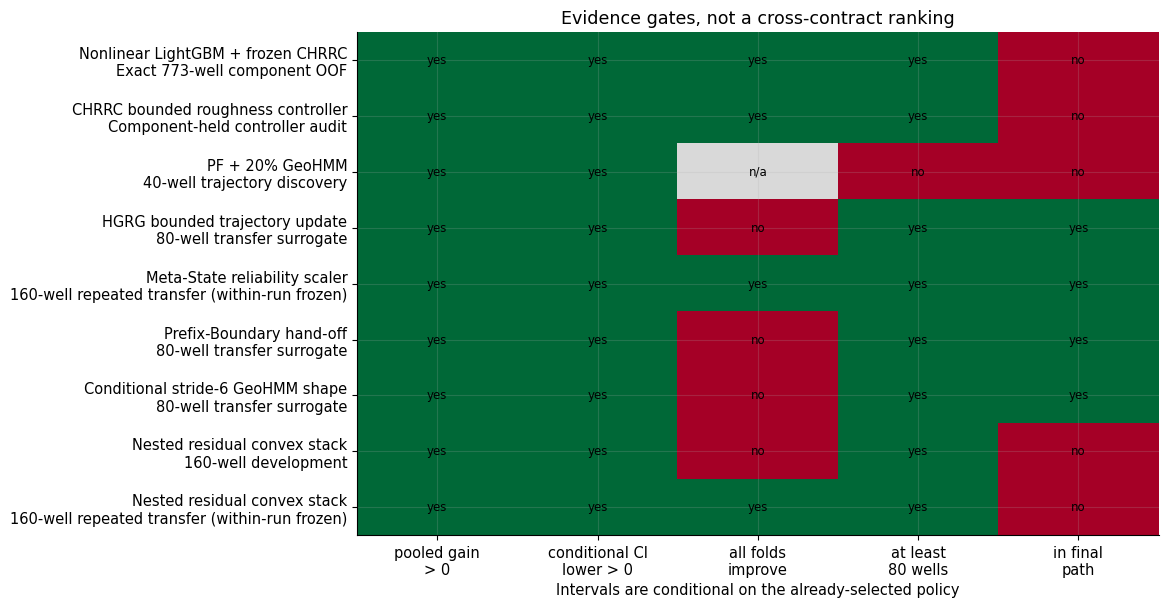

,experiment,contract,base_rmse,candidate_rmse,gain,ci_low,ci_high,positive_folds,folds
0,Nonlinear LightGBM + frozen CHRRC,Exact 773-well component OOF,13.6550,13.6065,0.0484,0.0421,0.0559,5.0000,5
1,CHRRC bounded roughness controller,Component-held controller audit,12.9483,12.8883,0.0600,0.0451,0.0776,5.0000,5
2,PF + 20% GeoHMM,40-well trajectory discovery,7.5072,6.5775,0.9297,0.2564,1.5277,NaN,5
3,HGRG bounded trajectory update,80-well transfer surrogate,7.8299,7.5006,0.3293,0.0189,0.6143,4.0000,5
4,Meta-State reliability scaler,160-well repeated transfer (within-run frozen),9.8871,9.1804,0.7067,0.2961,1.1109,5.0000,5
5,Prefix-Boundary hand-off,80-well transfer surrogate,7.4324,7.4141,0.0183,0.0096,0.0310,4.0000,5
6,Conditional stride-6 GeoHMM shape,80-well transfer surrogate,7.4324,7.4165,0.0160,0.0078,0.0266,4.0000,5
7,Nested residual convex stack,160-well development,9.5441,9.4644,0.0797,0.0120,0.1452,4.0000,5
8,Nested residual convex stack,160-well repeated transfer (within-run frozen),9.1804,9.1087,0.0717,0.0143,0.1355,5.0000,5


,component,contract,base_rmse,candidate_rmse,gain,incremental_compute,final_path,decision
0,HGRG,Exact80,7.8299,7.5006,0.3293,12-seed PF + stride-2 HMM,True,retain: material trajectory gain
1,Meta-State,Confirmation160,9.8871,9.1804,0.7067,RBF + GLS/RTS state,True,retain: strongest replicated overlay
2,Prefix-Boundary,Exact80,7.4324,7.4141,0.0183,prefix-only tangent,True,retain cautiously: cheap and interpretable
3,Conditional shape,Exact80 shape-only,7.4324,7.4165,0.0160,additional stride-6 HMM,True,marginal locally; end-to-end result observed
4,Nested residual stack,Confirmation160,9.1804,9.1087,0.0717,three residual experts + nested weights,False,exclude: only +0.0056 beyond best expert
5,CHRRC,component-held control,12.9483,12.8883,0.0600,centered rolling mean,False,"retain as robustness control, not final-path claim"
6,Nonlinear LightGBM + CHRRC,Exact773 component OOF,13.6550,13.6065,0.0484,five LightGBMs + smoother,False,standalone control; weak absolute base


In [6]:
final_components = {
    "HGRG bounded trajectory update",
    "Meta-State reliability scaler",
    "Prefix-Boundary hand-off",
    "Conditional stride-6 GeoHMM shape",
}
fold_gate = np.where(
    results.positive_folds.notna(),
    (results.positive_folds == results.folds).astype(float),
    np.nan,
)
gate_matrix = np.column_stack([
    (results.gain > 0).astype(float),
    (results.ci_low > 0).astype(float),
    fold_gate,
    (results.wells >= 80).astype(float),
    results.experiment.isin(final_components).astype(float),
])
cmap = plt.cm.RdYlGn.copy()
cmap.set_bad("#d9d9d9")
fig, ax = plt.subplots(figsize=(11.8, 6.2))
ax.imshow(gate_matrix, aspect="auto", cmap=cmap, vmin=0, vmax=1)
labels = [f"{name}\n{contract}" for name, contract in zip(results.experiment, results.contract)]
ax.set_yticks(np.arange(len(results)), labels)
ax.set_xticks(
    np.arange(5),
    ["pooled gain\n> 0", "conditional CI\nlower > 0", "all folds\nimprove", "at least\n80 wells", "in final\npath"],
)
for row_index in range(gate_matrix.shape[0]):
    for column_index in range(gate_matrix.shape[1]):
        value = gate_matrix[row_index, column_index]
        ax.text(
            column_index,
            row_index,
            "n/a" if np.isnan(value) else ("yes" if value else "no"),
            ha="center",
            va="center",
            fontsize=8.5,
        )
ax.set_title("Evidence gates, not a cross-contract ranking")
ax.set_xlabel("Intervals are conditional on the already-selected policy")
plt.tight_layout()
plt.show()
display(results[["experiment", "contract", "base_rmse", "candidate_rmse", "gain", "ci_low", "ci_high", "positive_folds", "folds"]])
display(complexity_ledger[["component", "contract", "base_rmse", "candidate_rmse", "gain", "incremental_compute", "final_path", "decision"]])

### RMSE ladders, same contract only

I only build a ladder chart when every point on it shares the same rows and parent contract, otherwise you get a ranking that looks convincing but is comparing apples to oranges. The left ladder isolates the trajectory contributions on Exact80; the right one isolates the later residual correction on Confirmation160. The asterisk marks the exploratory Boundary + shape composition, which never got a fresh, untouched confirmation panel.

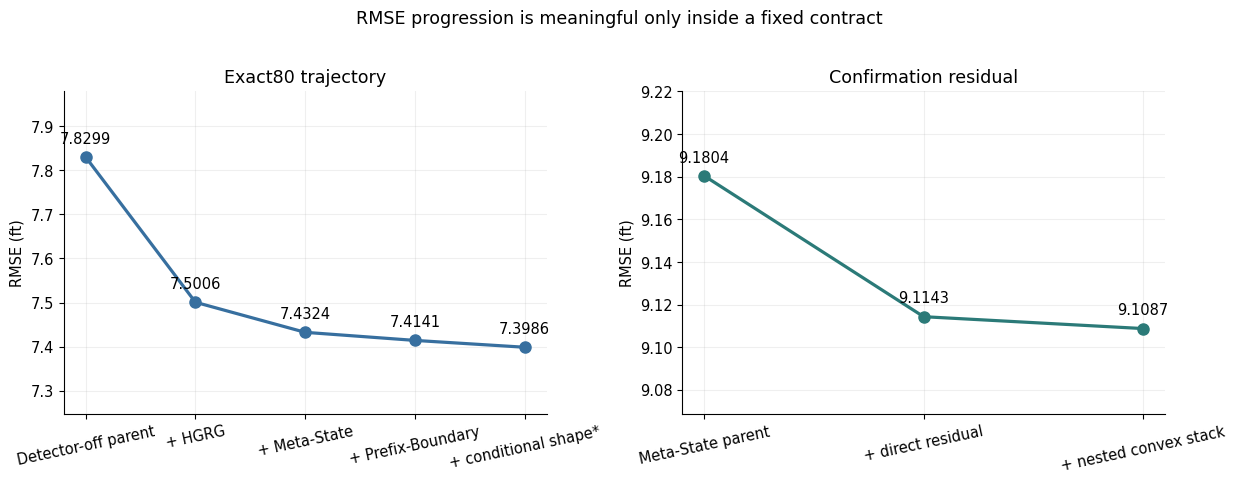

,contract,order,stage,rmse
0,Exact80 trajectory,0,Detector-off parent,7.8299
1,Exact80 trajectory,1,+ HGRG,7.5006
2,Exact80 trajectory,2,+ Meta-State,7.4324
3,Exact80 trajectory,3,+ Prefix-Boundary,7.4141
4,Exact80 trajectory,4,+ conditional shape*,7.3986
5,Confirmation residual,0,Meta-State parent,9.1804
6,Confirmation residual,1,+ direct residual,9.1143
7,Confirmation residual,2,+ nested convex stack,9.1087


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.7))
colors = ["#376f9f", "#2b7a78"]
for ax, (contract, group), color in zip(axes, rmse_ladders.groupby("contract", sort=False), colors):
    group = group.sort_values("order")
    ax.plot(group.order, group.rmse, marker="o", markersize=8, linewidth=2.3, color=color)
    ax.set_xticks(group.order, group.stage, rotation=12)
    ax.set_ylabel("RMSE (ft)")
    ax.set_title(contract)
    pad = max((group.rmse.max() - group.rmse.min()) * 0.35, 0.04)
    ax.set_ylim(group.rmse.min() - pad, group.rmse.max() + pad)
    for _, row in group.iterrows():
        ax.annotate(f"{row.rmse:.4f}", (row.order, row.rmse), xytext=(0, 10), textcoords="offset points", ha="center")
fig.suptitle("RMSE progression is meaningful only inside a fixed contract", y=1.02)
plt.tight_layout()
plt.show()
display(rmse_ladders)

### What the latest residual stack added

The nested hybrid moved development from 9.5441 to 9.4644 (+0.0797; 4/5 folds; component interval [+0.0120,+0.1452]). Once that gate passed, I scored the already-frozen predictions on the separate confirmation panel: 9.1804 to 9.1087 (+0.0717; 5/5; [+0.0143,+0.1355]).

That's a real result, but a small one. On confirmation, the stack only added 0.0056 ft beyond the best single residual expert, and the fold-wise weights weren't stable. I'm keeping it as a bounded overlay, not billing it as some one-foot breakthrough.

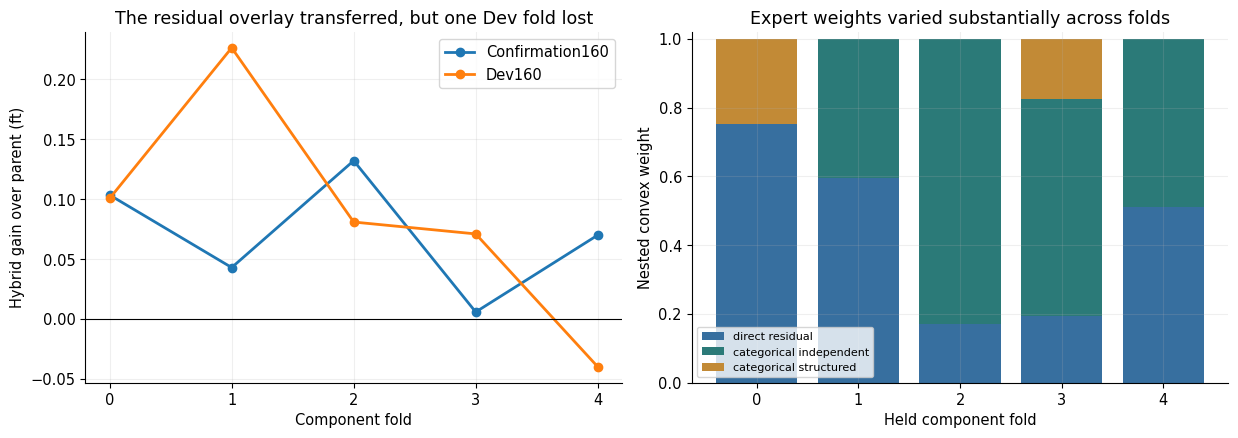

method,panel,fold,hybrid_convex,identity_parent,gain
0,Confirmation160,0,12.9964,13.0998,0.1034
1,Confirmation160,1,6.3328,6.3757,0.0429
2,Confirmation160,2,7.6237,7.7558,0.1321
3,Confirmation160,3,9.1072,9.1130,0.0058
4,Confirmation160,4,7.6453,7.7153,0.0700
5,Dev160,0,9.7474,9.8480,0.1007
6,Dev160,1,6.1381,6.3644,0.2263
7,Dev160,2,9.5202,9.6011,0.0809
8,Dev160,3,13.0488,13.1197,0.0710
9,Dev160,4,7.6406,7.6007,-0.0399


In [8]:
primary = stack_folds[stack_folds.method.isin(["identity_parent", "hybrid_convex"])]
pivot = primary.pivot(index=["panel", "fold"], columns="method", values="rmse").reset_index()
pivot["gain"] = pivot.identity_parent - pivot.hybrid_convex

hybrid_weights = stack_weights[stack_weights.objective.eq("hybrid")].copy()
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
for panel, group in pivot.groupby("panel", sort=False):
    axes[0].plot(group.fold, group.gain, marker="o", linewidth=2, label=panel)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xticks(range(5))
axes[0].set_xlabel("Component fold")
axes[0].set_ylabel("Hybrid gain over parent (ft)")
axes[0].set_title("The residual overlay transferred, but one Dev fold lost")
axes[0].legend()

experts = ["direct_residual", "categorical_independent", "categorical_structured"]
bottom = np.zeros(len(hybrid_weights))
colors = ["#376f9f", "#2b7a78", "#c28a36"]
for expert, color in zip(experts, colors):
    axes[1].bar(hybrid_weights.fold, hybrid_weights[expert], bottom=bottom, label=expert.replace("_", " "), color=color)
    bottom += hybrid_weights[expert].to_numpy()
axes[1].set_xticks(range(5))
axes[1].set_ylim(0, 1.02)
axes[1].set_xlabel("Held component fold")
axes[1].set_ylabel("Nested convex weight")
axes[1].set_title("Expert weights varied substantially across folds")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()
display(pivot)

## 5. What the wells taught me

**Long-range trend beats short-range polish.** Near the visible heel, local smoothing and DWT-style controls often looked great. That advantage disappeared or flipped at longer horizons. PF/HMM and the regional-state updates got more useful the farther out you went, because they're working with a whole structural trajectory instead of a local patch.

**A small tail of hard wells drives most of the error.** In the full component-safe reference, 70 wells with RMSE above 20 ft accounted for about 52.2% of all squared error. That's why I tracked harmed-well rate, p90 well RMSE, worst regret, and fold signs alongside pooled RMSE instead of just watching the headline number.

**Similarity alone doesn't tell you the right mode.** A well can have a high prefix-GR correlation with a completely different structural cycle. My chosen analogue didn't even beat a random-analogue baseline, which is why I ended up treating GR similarity as an uncertainty signal instead of a direct transport rule.

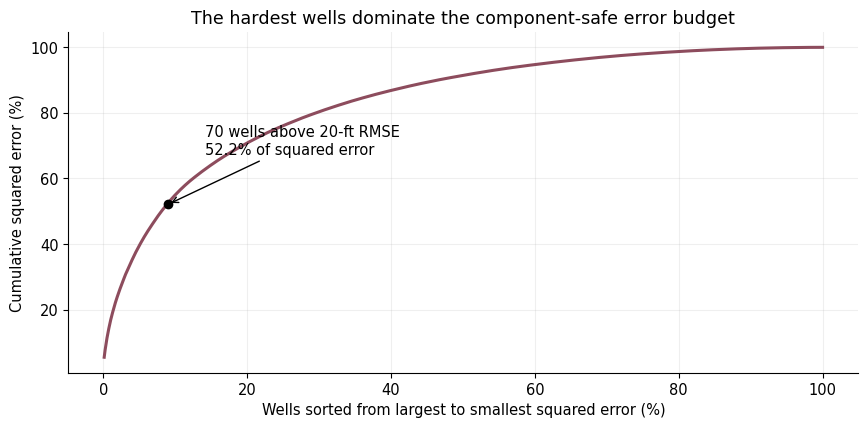

In [9]:
ranked = full_wells.assign(sse=full_wells.rows * full_wells.rmse**2).sort_values("sse", ascending=False)
ranked["well_fraction"] = np.arange(1, len(ranked) + 1) / len(ranked)
ranked["sse_fraction"] = ranked.sse.cumsum() / ranked.sse.sum()
tail = ranked[ranked.rmse > 20]
assert len(tail) == 70
tail_share = tail.sse.sum() / ranked.sse.sum()
assert np.isclose(tail_share, 0.5219, atol=5e-4)

fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.plot(100 * ranked.well_fraction, 100 * ranked.sse_fraction, color="#8d4c5d", linewidth=2.2)
point = (100 * len(tail) / len(ranked), 100 * tail_share)
ax.scatter(*point, color="black", zorder=3)
ax.annotate(
    f"{len(tail)} wells above 20-ft RMSE\n{100*tail_share:.1f}% of squared error",
    xy=point,
    xytext=(26, 36),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->", "color": "black"},
)
ax.set_xlabel("Wells sorted from largest to smallest squared error (%)")
ax.set_ylabel("Cumulative squared error (%)")
ax.set_title("The hardest wells dominate the component-safe error budget")
plt.tight_layout()
plt.show()

### RMSE vs. prediction horizon

A single pooled score hides where a correction is actually earning its keep, so I plotted absolute base/candidate RMSE against distance from the visible anchor. The panels are kept separate on purpose since their row populations differ. CHRRC gives a small, uniform correction across the board; PF/GeoHMM and the regional state are the ones actually tackling the growing long-range error.

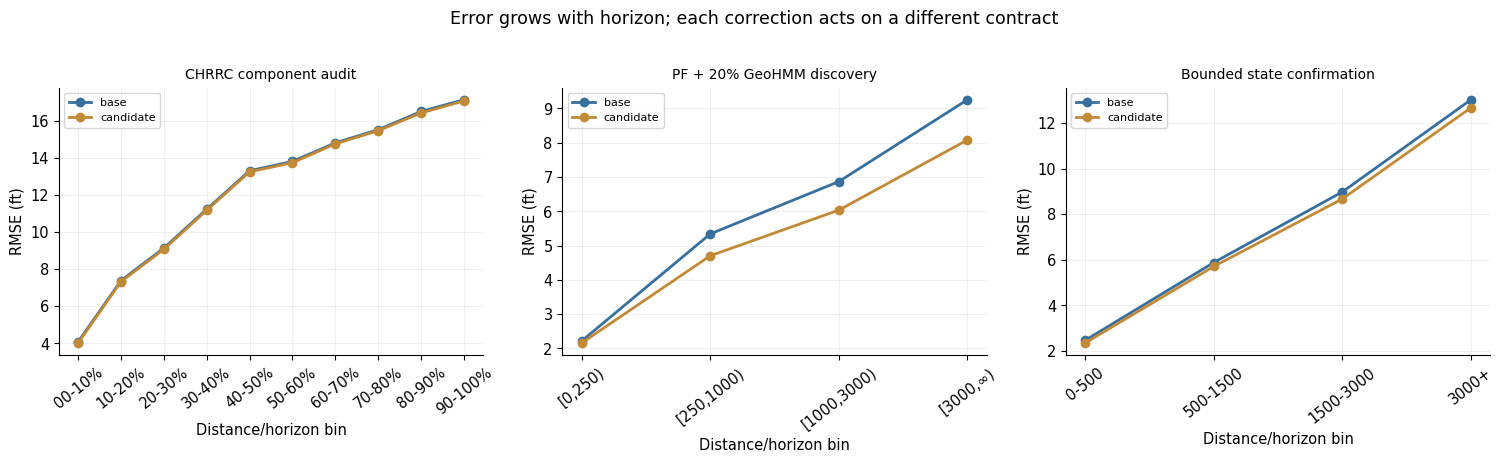

,contract,horizon,order,base_rmse,candidate_rmse,gain
0,CHRRC component audit,00-10%,0,4.0832,4.0167,0.0665
1,CHRRC component audit,10-20%,1,7.3856,7.3282,0.0574
2,CHRRC component audit,20-30%,2,9.1396,9.0751,0.0644
3,CHRRC component audit,30-40%,3,11.2381,11.1771,0.0610
4,CHRRC component audit,40-50%,4,13.3110,13.2532,0.0577
5,CHRRC component audit,50-60%,5,13.8162,13.7467,0.0695
6,CHRRC component audit,60-70%,6,14.8166,14.7611,0.0556
7,CHRRC component audit,70-80%,7,15.5260,15.4747,0.0512
8,CHRRC component audit,80-90%,8,16.5119,16.4322,0.0797
9,CHRRC component audit,90-100%,9,17.1464,17.0805,0.0660


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15.2, 4.5))
colors = ("#376f9f", "#c28a36")
for ax, (contract, group) in zip(axes, horizon_rmse.groupby("contract", sort=False)):
    group = group.sort_values("order")
    x = np.arange(len(group))
    ax.plot(x, group.base_rmse, marker="o", linewidth=2, color=colors[0], label="base")
    ax.plot(x, group.candidate_rmse, marker="o", linewidth=2, color=colors[1], label="candidate")
    ax.set_xticks(x, group.horizon, rotation=38)
    ax.set_xlabel("Distance/horizon bin")
    ax.set_ylabel("RMSE (ft)")
    ax.set_title(contract, fontsize=10)
    ax.legend(fontsize=8)
fig.suptitle("Error grows with horizon; each correction acts on a different contract", y=1.02)
plt.tight_layout()
plt.show()
display(horizon_rmse)

## 6. Negative results that actually shaped the design

I treated a failed transfer as evidence against a mechanism, not as a cue to go tune a new blend weight on the same labels.

### What overfitting looked like from the inside

My first mistake was assuming "different well IDs" meant independent geology. The leakage audit showed my ordinary folds still shared nearby wells, type-well curves, and near-identical GR structure, which made some of my early CV numbers overly optimistic. Rebuilding the split around geological relationship components made the score worse, but the question I was actually answering got a lot more honest.

My second mistake was **research-selection overfitting**. Exact80 and the 160-well panels stayed label-isolated inside each individual run, but I kept looking at them over and over while deciding what to try next. That turned them into engineering transfer panels rather than pristine holdouts. I label them that way now, and I won't mechanically turn their deltas into a hidden-score forecast.

When I say something is **frozen**, I mean the evaluated labels weren't used to refit that specific run, not that I'd never laid eyes on the panel during the project. A handful of constants were also just inherited from earlier iterations: I can reproduce them, but reproducing a number isn't the same as statistically identifying it. Wherever I can't point to a predeclared search on a panel I hadn't already seen, I call it a fixed heuristic and only credit the frozen whole-block ablation, not any single decimal weight.

Third, I sank too much time into refining one PF neighborhood. Tweaking the initial structural rate improved Dev40 by 0.561 ft with 5/5 folds and a positive interval, and then lost 1.792 ft on Exact80. More seeds, more particles, observation tempering, process-noise tweaks, resampling variants, mostly all exploring the same local mechanism. The real lesson was to compare mechanistically different ideas (boundary continuity, regional state, alignment shape, nonlinear residual controls) and demand a frozen transfer before adding more complexity to any one of them.

I also learned that a good-looking decomposition can be an illusion. A horizon-banded selector looked like it gained 1.011 ft, but every single band had picked the exact same 0.30 PF weight and produced a byte-identical global blend. That's not evidence of horizon-specific physics, it's just RMSE fooling me. Hashes and null controls caught what RMSE alone would have let me believe.

My fourth mistake was operational sampling bias. My runtime canary only used protected train-overlap wells, so the expensive hidden-only shape branch never actually ran during testing, it checked file integrity and the common parent, not the workload I actually needed to finish in time. A representative runtime panel needs to be stratified by overlap status, suffix length, HMM state count, and worst-case well complexity.

### What actually worked

The strongest part of this project wasn't any single optimizer setting, it was a control-first pipeline: predict the structural coordinate $U$, keep related geology inside one fold, freeze each policy before transfer, use whole-component uncertainty, and cap every physical correction with a well-level movement budget. HGRG and Meta-State delivered the biggest transferable trajectory gains; Prefix-Boundary and the zero-mean conditional shape layer added small, interpretable corrections on top. The final hidden result is encouraging, but one hidden evaluation is still just one outcome, not proof that every individual piece caused the improvement.

A few things that didn't survive contact with a frozen panel:

- a longer heel-slope initialization helped a lot on development and then failed badly on transfer, so I went back to the short, robust initialization;
- a directional structural field was physically appealing and improved every discovery fold, then reversed on a frozen panel, I zeroed its weight;
- a learned regret router had a lot of oracle headroom but couldn't reliably tell which direction to correct in, so its fail-closed output was just the parent prediction;
- a horizon-banded PF policy looked like it gained 1.011 ft, but every band picked the same 0.30 coefficient and matched a global PF30 control byte-for-byte, no horizon-specific mechanism there;
- swapping measured-depth increments for 3-D chord increments was a reasonable-sounding fix that improved the discovery PF by 0.170 ft and then lost 0.078 ft on transfer;
- DTRT can transport same-well suffix targets exactly when there's an overlap, but I only kept it around as an overlap diagnostic, it's not valid for the hidden-well methodology.

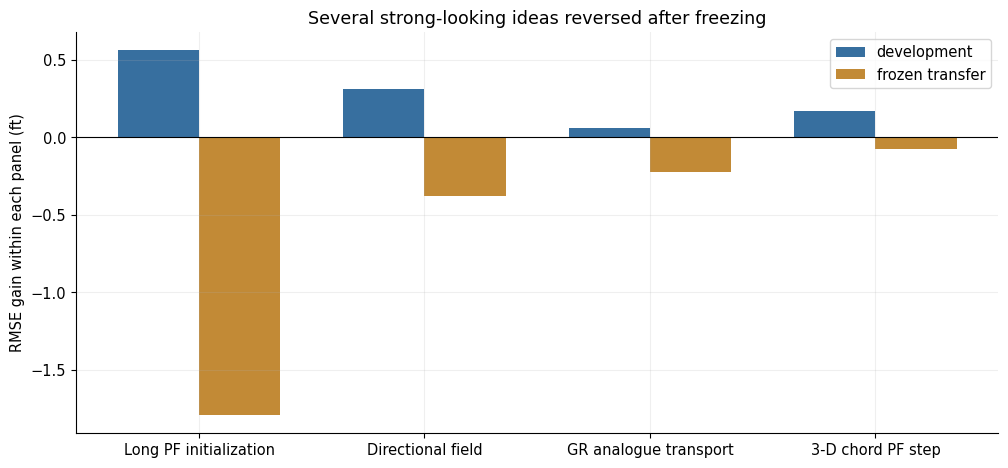

,hypothesis,development_gain,transfer_gain,decision,lesson
0,A longer heel-slope initialization should stabilize PF,0.5610,-1.7920,reject,a nonlinear filter can enter a different GR phase after a seemingly stable local improvement
1,A cross-well directional structural field should transfer local dip,0.3110,-0.3830,reject,physical plausibility did not make the correction invariant to the parent residual contract
2,The most similar prefix GR analogue should reveal the future structural mode,0.0580,-0.2240,reject,selected similarity did not beat the random-analogue null
3,A learned regret router can choose the best expert per well,-0.0850,0.0000,fail closed,disagreement predicted difficulty better than the sign of the correction
4,A prefix-calibrated pseudo type-well should repair clean wells,-2.7400,NaN,reject,affine intervention recovery did not imply clean-data generalization
5,Different horizon bands require different PF weights,1.0110,NaN,hold,all bands saturated at 0.30 and were byte-identical to one global PF30 control
6,3-D chord increments are a better PF time step than measured depth,0.1700,-0.0780,reject,the mathematically plausible step correction was unstable across panels
7,Same-well suffix target transport is a valid hidden-well model,NaN,NaN,exclude,DTRT is a useful overlap diagnostic but violates the hidden-generalization contract


In [11]:
plot = transfer_pairs.copy()
plot = plot[~plot.hypothesis.str.contains("router")].reset_index(drop=True)
short = [
    "Long PF initialization",
    "Directional field",
    "GR analogue transport",
    "3-D chord PF step",
]
x = np.arange(len(plot))
width = 0.36
fig, ax = plt.subplots(figsize=(10.2, 4.8))
ax.axhline(0, color="black", linewidth=0.8)
ax.bar(x - width/2, plot.development_gain, width, label="development", color="#376f9f")
ax.bar(x + width/2, plot.transfer_gain, width, label="frozen transfer", color="#c28a36")
ax.set_xticks(x, short)
ax.set_ylabel("RMSE gain within each panel (ft)")
ax.set_title("Several strong-looking ideas reversed after freezing")
ax.legend()
plt.tight_layout()
plt.show()
display(negatives[["hypothesis", "development_gain", "transfer_gain", "decision", "lesson"]])

## 7. Uncertainty and well-specific behavior

I leaned on two different kinds of uncertainty.

**Prediction-time uncertainty** came from PF–HMM disagreement, visible-prefix rolling-origin error, disagreement between the regional state and HGRG, and the spread across residual experts. These scale a correction up or down and can force abstention, they're not calibrated probabilities, just useful risk signals.

**Evaluation uncertainty** came from bootstrapping whole geological components, checking all five fold signs, and tracking harmed-well and worst-well regret. A row-level bootstrap would be way too confident here, since thousands of rows in the same well share basically the same geological error.

The problem I never fully solved is sign uncertainty. Expert disagreement is great for flagging a difficult well, but a difficult well might need correcting in either direction, you can't always tell which. The learned gate I built for the residual stack could spot rough predictions just fine, but it still made confirmation RMSE worse. That's the whole reason the final policy leans on continuous shrinkage and hard movement budgets instead of a confident on/off switch.

## 8. Where I drew the line

Every component I kept has a clear job:

- $U=TVT+Z$ stands for a structural surface, not borehole motion;
- the heel anchors datum and local continuity;
- PF propagates uncertainty through measured depth;
- GeoHMM captures ambiguous GR alignment over the full path;
- the regional state supplies training-side datum, slope, and curvature;
- HGRG and Meta-State express distrust through bounded movement, not confidence;
- CHRRC cleans up local numerical/model roughness without touching the long trend.

Where I drew a hard line: target transport, label-fitted well routing, and post-hoc weight selection. A physically sensible formula can still overfit, and a low RMSE from a control that's secretly reading the target isn't a generalization result. Whenever a frozen transfer failed, I'd rather zero the weight than keep tuning.

## 9. Limitations, and what I'd run next

The main limitation: my strongest trajectory components still don't share one fully nested, full-population parent. The 40-, 80-, and 160-well panels were built for different stages of the research loop, so I can't claim their gains stack, and the final hidden result doesn't retroactively fix that missing ablation.

What I actually need next is a **single-parent end-to-end audit**, not another round of weight sweeping:

1. lock a component-disjoint confirmation set before looking at any new result;
2. build outer folds on the remaining geological components and fit every imputer, feature transform, ML model, state surface, gate, and blend weight inside the matching training side;
3. produce one common row-aligned OOF ladder, incumbent, +HGRG, +Meta, +Boundary, +shape, so every incremental RMSE shares the same population and immediate parent;
4. report each stage against both its parent and the best simpler alternative, along with component-bootstrap uncertainty, harmed-well rate, worst regret, wall time, and memory;
5. apply a predeclared one-standard-error/complexity rule to cut any component whose gain can't be told apart from a simpler path;
6. freeze once, run the untouched confirmation once, and only then start profiling the exact hidden inference graph.

I'd also like to rebuild the categorical alignment model at a finer TVT resolution and learn a hierarchical uncertainty loss with component-balanced regret, but only once that common OOF parent exists. Until that audit happens, the honest claim is narrower than I'd like: the mechanisms produced useful evidence inside their own contracts, and the combined path hit an encouraging hidden score, but it's not a fully identified, additive decomposition yet.

## 10. Final result and the operational lesson

My final [Boundary + Meta-State + HGRG + conditional GeoHMM-shape candidate](https://www.kaggle.com/code/baytree1238/rogii-boundary-meta-shape-geohmm-optional-v1) landed at **6.536** on the visible partition and **9.091** on the hidden one. I checked the leaderboard display myself, and 9.091 sat comfortably inside the bronze range.

I never actually got that medal, though. Scoring for that submission didn't finish until after the official competition deadline, which meant it couldn't be counted for final selection. That stung, because the result showed the complete, fixed trajectory stack was genuinely competitive, my execution plan just didn't get it across the line in time. I'm treating 9.091 as one end-to-end observation: without matching hidden ablations, it can't tell me which overlay actually caused the result, and the visible–hidden gap isn't a clean overfitting estimate either, since the two populations and active branches weren't the same.

This was a time-management and experimental-design failure more than a pure infrastructure surprise. I'd cached the immutable 773-well structural summary with a hash check, reused upstream PF/HMM arrays, parallelized independent seeds and wells across four CPU workers, and restored canonical seed/order before aggregating, all of which preserved the algorithms and prediction order just fine. The problem was that my three-well runtime canary finished its model audit in about 796 seconds and its full log in about 811 seconds only because all three visible wells happened to be protected overlaps, so the expensive hidden-only smoother never actually ran. That canary checked schema, finite predictions, checksums, and code connectivity, it told me nothing about hidden-scale inference time or queue latency. I should have profiled representative non-overlap wells, measured the actual per-well scaling, frozen the candidate, and submitted a lot earlier. In a code competition, the model, the queue, and the hidden execution time are all part of the methodology, not separate concerns.

I still count this as a valuable experience. It changed how I think about what "reproducible" actually means for a solution like this: you need a measured runtime budget, per-well checkpoints, cached deterministic intermediates, restart tests, and real launch margin ahead of the scoring queue. Those aren't presentation details you bolt on after modeling, they're the conditions under which the method can actually be evaluated at all. The scientific lesson held up too: small, bounded corrections can transfer well when they encode genuinely different physical constraints, but only a frozen, component-safe, and operationally executable pipeline actually earns the word "solution."

## Closing reflection

The most useful outcome of all this wasn't any single mechanism, it was a better research loop: define the physical state, isolate related geology, freeze one mechanism at a time, transfer it, and go look at whichever wells got hurt. The PF/GeoHMM/HGRG/Meta-State family survived that loop better than the alternatives, but the uncertainty that's still left is scientifically important in its own right.

If I started over, I'd nail down the component-safe contract before tuning the first model. That one decision alone would save more time than another big hyperparameter search, and it'd make every result after it easier to actually trust.

Somewhere in the middle of this, I realized the competition had quietly enrolled me in a small math degree. The particle filter sent me back to Bayesian filtering and Monte Carlo approximation; GeoHMM meant relearning forward–backward dynamic programming; Meta-State pulled in covariance modeling and Rauch–Tung–Striebel smoothing; leakage control turned into a graph connected-components problem; CHRRC and Savitzky–Golay made signal processing unavoidable; and the movement budgets turned blending into constrained robust optimization. So my only half-joking conclusion is also true: I probably need to study a lot more math, ideally before the next deadline, not while staring at the submission queue. The practical goal going forward is fewer unexplained magic decimals, more quantities actually derived from a model, and clearer experiments whenever a derivation is only an approximation.

This whole project was built for the [ROGII – Wellbore Geology Prediction](https://www.kaggle.com/competitions/rogii-wellbore-geology-prediction) competition on Kaggle.